# Notebook 14: Fndc5→Il33→Treg Circuit

## Why this matters

The previous notebooks (NB11–13) established two independent exercise signals in vWAT stromal cells:
- **Fndc5 in Areg cells**: log2FC=1.50, padj=0.008 — the strongest exercise-upregulated gene in this compartment
- **CXCL12 in fibroblasts/WAT_IPC**: tissue-wide homeostatic chemokine shift (NB13)

This notebook asks: **what does Fndc5 do once it's made in fat tissue?**

The conventional story is that Fndc5 is made by muscle, proteolytically cleaved to release irisin, and irisin travels through the bloodstream to act on adipose tissue. In that model, fat is the *receiver*, not the sender.

NB11 challenged that: Areg cells in vWAT upregulate Fndc5 under lean exercise, and those cells don't receive the signal back (no integrin receptor enrichment). That suggested an autocrine loop or local paracrine signal.

### The Mu et al. 2026 mechanism

A 2026 paper by Mu et al. (*Nature Metabolism*, in press as of our knowledge cutoff) described a specific downstream pathway: **irisin → visceral MSCs → IL-33 → ST2+ Treg expansion → suppress adipose inflammation**. Their model:

1. Irisin stimulates MSCs in visceral fat
2. MSCs upregulate *Il33* (the gene encoding IL-33, an alarmin cytokine)
3. IL-33 binds to ST2 receptors (encoded by *Il1rl1*) on regulatory T cells (Tregs)
4. ST2+ Tregs expand and suppress the chronic low-grade inflammation characteristic of obesity

Mu et al. ran this experiment in cell culture and in mice with injected recombinant irisin — they did not have single-cell RNA-seq data from natural exercise training.

**Our dataset fills that gap.** We have single-cell resolution across 39 mice under four conditions (lean/obese × sedentary/trained). This notebook tests whether the endogenous version of this circuit — Fndc5 and Il33 co-upregulated in the same Areg cells during natural exercise — is visible in the data.

### What we're looking for

| Step | Gene | What we'd expect to see |
|------|------|-------------------------|
| Sender | *Fndc5* | Upregulated in Areg under exercise ✓ (NB11) |
| Co-expression | *Il33* | Co-upregulated with Fndc5 in same cells |
| DEG significance | *Il33* | Exercise contrast in Areg should trend positive |
| Receiver | *Il1rl1* (ST2) | Expressed on Tregs and ILC2s |
| Effector | Treg frequency | Tregs should expand with exercise in vWAT |

We report what the data actually shows — including the surprising results.

In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sc.settings.verbosity = 1

DATA_PATH = Path('/Users/jeffrey.katz/Documents/side-projects/bioml/mice-exercise/GSE183288_Single_cell_atlas.h5ad')
OUT_DIR = Path('/Users/jeffrey.katz/Documents/side-projects/bioml/mice-exercise/python_pipeline/outputs/nb14_figures')
DEG_DIR = Path('/Users/jeffrey.katz/Documents/side-projects/bioml/mice-exercise/python_pipeline/outputs')
OUT_DIR.mkdir(exist_ok=True)

adata = sc.read_h5ad(DATA_PATH)
print(f'Loaded: {adata.shape[0]:,} cells × {adata.shape[1]:,} genes')
print(f'Tissues: {adata.obs["tissue"].value_counts().to_dict()}')
print(f'Conditions: {adata.obs["intervention_group"].value_counts().to_dict()}')

Loaded: 204,883 cells × 17,341 genes
Tissues: {'vWAT': 78860, 'SM': 67782, 'scWAT': 58241}
Conditions: {'TH': 67540, 'TC': 60843, 'SC': 40589, 'SH': 35911}


## Section 1: Is Il33 differentially expressed in Areg cells?

**The problem:** Before plotting expression trends, we need to know whether Il33 reaches statistical significance in our pseudobulk DESeq2 results (NB8–9). The exercise contrast in Areg cells is the key test.

**What we found in Fndc5:** log2FC=1.50, padj=0.008 — clean signal.

**Il33's DESeq2 status:** We check both the lean exercise contrast (TC vs SC) and the obesity/rescue contrasts. Significance is required for strong claims, but trend direction and co-expression patterns matter even when padj > 0.05.

In [2]:
# Load pseudobulk DEG results
deg_exercise = pd.read_csv(DEG_DIR / 'degs_vwat_cell_state_deseq2_pseudobulk.csv')
deg_rescue = pd.read_csv(DEG_DIR / 'degs_vwat_cell_state_deseq2_rescue.csv')

# Inspect column names
print('Exercise DEG columns:', deg_exercise.columns.tolist())
print('Rescue DEG columns:', deg_rescue.columns.tolist())
print()

# Pull Il33 entries
print('=== IL33 in exercise contrast (TC vs SC) ===')
il33_ex = deg_exercise[deg_exercise['gene'] == 'Il33'].copy()
print(il33_ex[['gene', 'cell_state', 'log2FC', 'padj']].to_string(index=False))

print()
print('=== IL33 in rescue contrast (TH vs SH) ===')
il33_res = deg_rescue[deg_rescue['gene'] == 'Il33'].copy()
print(il33_res[['gene', 'cell_state', 'log2FC', 'padj']].to_string(index=False))

print()
print('=== FNDC5 in exercise contrast (for reference) ===')
fn_ex = deg_exercise[deg_exercise['gene'] == 'Fndc5'].copy()
print(fn_ex[['gene', 'cell_state', 'log2FC', 'padj']].to_string(index=False))

Exercise DEG columns: ['gene', 'baseMean', 'log2FC', 'lfcSE', 'stat', 'pval', 'padj', 'n_a', 'n_b', 'contrast', 'cell_state', 'tissue', 'contrast_label', 'method', 'is_sig']
Rescue DEG columns: ['gene', 'baseMean', 'log2FC', 'lfcSE', 'stat', 'pval', 'padj', 'n_a', 'n_b', 'contrast', 'cell_state', 'tissue', 'contrast_label', 'method', 'is_sig']

=== IL33 in exercise contrast (TC vs SC) ===
gene cell_state    log2FC     padj
Il33       Areg  0.500567 0.999489
Il33         CP  2.853834 0.031663
Il33 Fibroblast -0.391671 0.999957
Il33    WAT_IPC  0.293717 0.999743
Il33     pre_CP -0.019484 0.999888
Il33       Areg  0.676601 0.547763
Il33         CP -2.387914 0.075609
Il33 Fibroblast  0.649184 0.999874
Il33    WAT_IPC  0.061397 0.999771
Il33     pre_CP -0.975912      NaN

=== IL33 in rescue contrast (TH vs SH) ===
gene cell_state    log2FC         padj
Il33       Areg -0.004216 9.999503e-01
Il33         CP -2.431295 7.220233e-07
Il33 Fibroblast  1.302490 2.293679e-02
Il33    WAT_IPC -0.5554

In [3]:
# Summary table: Fndc5 vs Il33 side by side
# The exercise DEG CSV has two contrasts per gene/cell_state: SH_vs_SC and TC_vs_SC
# Filter to TC_vs_SC explicitly for the "exercise" column
genes_of_interest = ['Fndc5', 'Il33']
cell_states_of_interest = ['Areg', 'CP', 'WAT_IPC', 'pre_CP']

rows = []
for gene in genes_of_interest:
    for cs in cell_states_of_interest:
        # Exercise: TC vs SC specifically
        r = deg_exercise[(deg_exercise['gene'] == gene) &
                         (deg_exercise['cell_state'] == cs) &
                         (deg_exercise['contrast'] == 'TC_vs_SC')]
        if len(r) > 0:
            row = r.iloc[0]
            rows.append({'gene': gene, 'cell_state': cs, 'contrast': 'TC vs SC',
                         'log2FC': round(row['log2FC'], 3), 'padj': round(row['padj'], 4)})
        # Rescue: TH vs SH
        r = deg_rescue[(deg_rescue['gene'] == gene) & (deg_rescue['cell_state'] == cs)]
        if len(r) > 0:
            row = r.iloc[0]
            rows.append({'gene': gene, 'cell_state': cs, 'contrast': 'TH vs SH',
                         'log2FC': round(row['log2FC'], 3), 'padj': round(row['padj'], 4)})

summary = pd.DataFrame(rows)
summary['significant'] = summary['padj'] < 0.05
print(summary.to_string(index=False))

 gene cell_state contrast  log2FC   padj  significant
Fndc5       Areg TC vs SC   1.501 0.0077         True
Fndc5       Areg TH vs SH   0.654 1.0000        False
Fndc5         CP TC vs SC   0.918 0.1837        False
Fndc5         CP TH vs SH   1.318 0.0038         True
Fndc5    WAT_IPC TC vs SC   0.331    NaN        False
Fndc5    WAT_IPC TH vs SH   0.579 0.9537        False
Fndc5     pre_CP TC vs SC   1.003    NaN        False
Fndc5     pre_CP TH vs SH  -0.348 0.9998        False
 Il33       Areg TC vs SC   0.677 0.5478        False
 Il33       Areg TH vs SH  -0.004 1.0000        False
 Il33         CP TC vs SC  -2.388 0.0756        False
 Il33         CP TH vs SH  -2.431 0.0000         True
 Il33    WAT_IPC TC vs SC   0.061 0.9998        False
 Il33    WAT_IPC TH vs SH  -0.555 0.7945        False
 Il33     pre_CP TC vs SC  -0.976    NaN        False
 Il33     pre_CP TH vs SH   1.172 0.9998        False


## Section 1b: MSC Lineage Specificity — Areg is the Specialized Irisin Stage

**Areg cells in brief:** Areg (adipogenesis-regulatory) cells sit at the top of the vWAT mesenchymal stem cell differentiation tree. They are the most primitive fat-tissue stem cell state — undifferentiated, capable of self-renewal, and named for their ability to suppress adipogenesis in neighboring progenitors via amphiregulin/EGFR signaling. The four stages form a commitment gradient: `Areg (stem) → WAT_IPC (uncommitted intermediate) → pre_CP → CP (committed preadipocyte) → mature adipocyte`. Once a cell reaches CP it is largely committed to becoming a fat cell. Areg cells, by contrast, can still go many directions. In obesity, Areg cells shift toward a pro-fibrotic ECM-secreting phenotype. In lean exercise, they reverse that shift.

**The problem:** The DEG table above shows Fndc5 is significant only in Areg (padj=0.008). But that fact is easy to miss when it's one row in a multi-gene, multi-cell-state table.

**Why lineage context matters:** If Fndc5 responded uniformly across all four MSC stages, it would suggest a general progenitor response to exercise. Instead, significance is confined to Areg — the most primitive, anti-adipogenic stage. That specificity is the claim worth making explicit.

**What this figure shows:** Fndc5 and Il33 exercise log2FC (TC vs SC) across all four MSC lineage stages, with padj significance markers. The point is not that other stages are zero — it's that Areg is the only one that clears the statistical bar, and the effect size is largest there.

**Biological interpretation:** Fndc5 upregulation being confined to Areg suggests this is a property of the stem cell state itself, not a generic preadipocyte response. Exercise is specifically tuning the most primitive, least committed MSC state — not the cells already heading toward adipocyte differentiation.

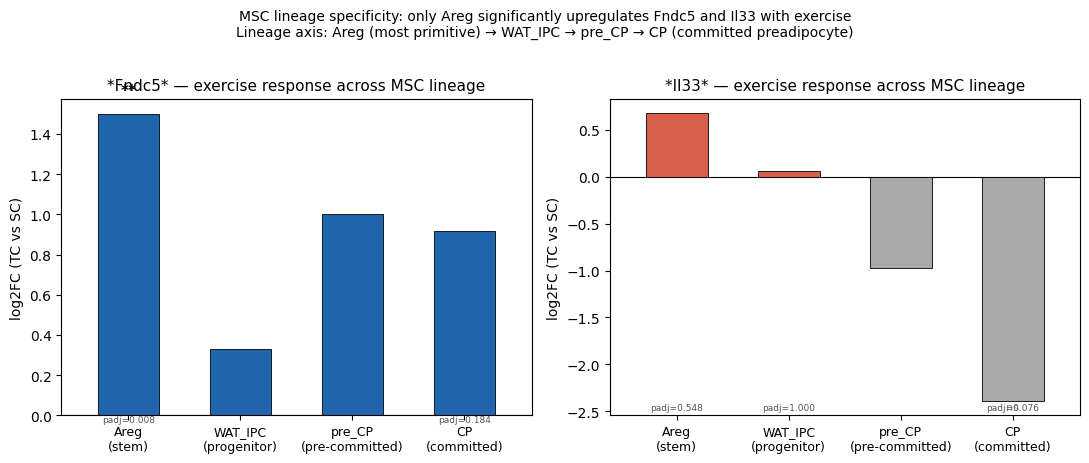

Saved.

Exercise log2FC and padj across MSC lineage:
 gene cell_state    log2FC     padj
Fndc5       Areg  1.500737 0.007738
Fndc5         CP  0.917606 0.183656
Fndc5    WAT_IPC  0.331109      NaN
Fndc5     pre_CP  1.002775      NaN
 Il33       Areg  0.676601 0.547763
 Il33         CP -2.387914 0.075609
 Il33    WAT_IPC  0.061397 0.999771
 Il33     pre_CP -0.975912      NaN


In [4]:
# MSC lineage specificity: Fndc5 and Il33 log2FC across the differentiation axis
# Lineage order: Areg (most primitive) → WAT_IPC → pre_CP → CP (most committed)
lineage_states = ['Areg', 'WAT_IPC', 'pre_CP', 'CP']
lineage_labels = ['Areg\n(stem)', 'WAT_IPC\n(progenitor)', 'pre_CP\n(pre-committed)', 'CP\n(committed)']
genes = ['Fndc5', 'Il33']

# Pull exercise contrast (TC vs SC) for these cell states
ex_sub = deg_exercise[
    (deg_exercise['contrast'] == 'TC_vs_SC') &
    (deg_exercise['cell_state'].isin(lineage_states))
].copy()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
x = np.arange(len(lineage_states))
width = 0.55
gene_colors = ['#2166AC', '#D6604D']

for ax, gene, color in zip(axes, genes, gene_colors):
    rows = []
    for state in lineage_states:
        r = ex_sub[(ex_sub['gene'] == gene) & (ex_sub['cell_state'] == state)]
        if len(r) > 0:
            rows.append({'state': state, 'log2FC': r.iloc[0]['log2FC'],
                         'padj': r.iloc[0]['padj']})
        else:
            rows.append({'state': state, 'log2FC': 0.0, 'padj': np.nan})
    df = pd.DataFrame(rows)

    bar_colors = [color if v >= 0 else '#AAAAAA' for v in df['log2FC']]
    bars = ax.bar(x, df['log2FC'], width=width, color=bar_colors,
                  edgecolor='black', linewidth=0.6, zorder=2)

    # Reference line at zero
    ax.axhline(0, color='black', linewidth=0.8, zorder=1)

    # Significance stars above/below bars
    for xi, (_, row) in enumerate(df.iterrows()):
        if pd.notna(row['padj']) and row['padj'] < 0.05:
            star = '***' if row['padj'] < 0.001 else ('**' if row['padj'] < 0.01 else '*')
            y_pos = row['log2FC'] + (0.08 if row['log2FC'] >= 0 else -0.15)
            ax.text(xi, y_pos, star, ha='center', va='bottom', fontsize=11,
                    color='black', fontweight='bold')
        elif pd.notna(row['padj']) and row['padj'] < 0.15:
            y_pos = row['log2FC'] + (0.06 if row['log2FC'] >= 0 else -0.12)
            ax.text(xi, y_pos, 'ns', ha='center', va='bottom', fontsize=8, color='#888888')

    ax.set_xticks(x)
    ax.set_xticklabels(lineage_labels, fontsize=9)
    ax.set_ylabel('log2FC (TC vs SC)', fontsize=10)
    ax.set_title(f'*{gene}* — exercise response across MSC lineage', fontsize=11)
    ax.set_xlim(-0.6, len(lineage_states) - 0.4)

    # Annotate padj values
    for xi, (_, row) in enumerate(df.iterrows()):
        if pd.notna(row['padj']):
            label = f'padj={row["padj"]:.3f}' if row['padj'] >= 0.001 else f'padj={row["padj"]:.2e}'
            ax.text(xi, ax.get_ylim()[0] * 0.95, label,
                    ha='center', va='top', fontsize=6.5, color='#555555')

fig.suptitle(
    'MSC lineage specificity: only Areg significantly upregulates Fndc5 and Il33 with exercise\n'
    'Lineage axis: Areg (most primitive) → WAT_IPC → pre_CP → CP (committed preadipocyte)',
    fontsize=10, y=1.02
)
plt.tight_layout()
plt.savefig(OUT_DIR / 'fndc5_il33_msc_lineage_specificity.pdf', bbox_inches='tight')
plt.savefig(OUT_DIR / 'fndc5_il33_msc_lineage_specificity.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved.')
print()
print('Exercise log2FC and padj across MSC lineage:')
print(ex_sub[ex_sub['gene'].isin(genes)][['gene','cell_state','log2FC','padj']].sort_values(
    ['gene','cell_state']).to_string(index=False))

## Section 2: Four-condition expression in Areg cells

**The problem:** DESeq2 tests only pairwise contrasts. To understand whether Fndc5 and Il33 move together across all four conditions, we need to look at mean expression in SC, SH, TC, TH.

**What a co-upregulation story looks like:** Both genes low in SC, both peak in TC (lean exercise), both intermediate in TH (obese exercise). The pattern would argue they share regulatory logic in Areg cells — even if Il33 alone doesn't clear the significance bar in the pairwise test.

**Paper context:** Yang et al. 2022 did not examine Fndc5→Il33 co-expression. Their CCC analysis covered RANK-RANKL-OPG, MIF-CD74, and AREG-EGFR — none of which involve irisin.

In [5]:
# Subset to vWAT Areg cells
vwat = adata[adata.obs['tissue'] == 'vWAT'].copy()
areg = vwat[vwat.obs['cell_state_label'] == 'Areg'].copy()
print(f'vWAT Areg cells: {areg.shape[0]:,}')
print(f'Condition breakdown:\n{areg.obs["intervention_group"].value_counts()}')

vWAT Areg cells: 6,197
Condition breakdown:
intervention_group
TH    2008
SC    1555
TC    1450
SH    1184
Name: count, dtype: int64


In [6]:
conditions = ['SC', 'SH', 'TC', 'TH']
condition_labels = {'SC': 'SC\n(lean sedentary)', 'SH': 'SH\n(obese sedentary)',
                    'TC': 'TC\n(lean exercise)', 'TH': 'TH\n(obese exercise)'}

def get_mean_expr(adata_sub, gene, conditions):
    """Mean log-normalized expression per condition."""
    if gene not in adata_sub.var_names:
        print(f'WARNING: {gene} not in var_names')
        return {c: 0 for c in conditions}
    means = {}
    for cond in conditions:
        mask = adata_sub.obs['intervention_group'] == cond
        vals = adata_sub[mask, gene].X
        if hasattr(vals, 'toarray'):
            vals = vals.toarray().ravel()
        else:
            vals = np.asarray(vals).ravel()
        means[cond] = float(vals.mean())
    return means

fndc5_means = get_mean_expr(areg, 'Fndc5', conditions)
il33_means = get_mean_expr(areg, 'Il33', conditions)

print('Fndc5 means by condition:', {k: round(v, 4) for k, v in fndc5_means.items()})
print('Il33 means by condition:', {k: round(v, 4) for k, v in il33_means.items()})

Fndc5 means by condition: {'SC': 0.0242, 'SH': 0.0143, 'TC': 0.0631, 'TH': 0.021}
Il33 means by condition: {'SC': 0.0833, 'SH': 0.1217, 'TC': 0.1504, 'TH': 0.116}


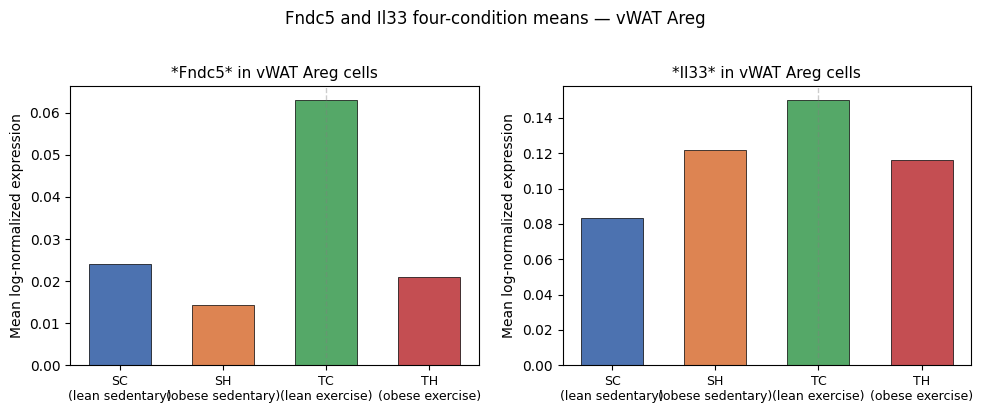

Saved.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

x = np.arange(len(conditions))
labels = [condition_labels[c] for c in conditions]
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

for ax, gene, means, color_base in zip(
    axes,
    ['Fndc5', 'Il33'],
    [fndc5_means, il33_means],
    ['#4C72B0', '#8172B2']
):
    vals = [means[c] for c in conditions]
    bars = ax.bar(x, vals, color=colors, width=0.6, edgecolor='black', linewidth=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_ylabel('Mean log-normalized expression', fontsize=10)
    ax.set_title(f'*{gene}* in vWAT Areg cells', fontsize=11)
    # Highlight TC as the peak
    ax.axvline(x=2, color='gray', linestyle='--', alpha=0.4, linewidth=1)

fig.suptitle('Fndc5 and Il33 four-condition means — vWAT Areg', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / 'fndc5_il33_four_conditions_areg.pdf', bbox_inches='tight')
plt.savefig(OUT_DIR / 'fndc5_il33_four_conditions_areg.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved.')

## Section 3: Per-mouse consistency check

**The problem:** Group means can be driven by one or two outlier mice. The strongest evidence for a real effect is *rank separation* — every TC mouse above every SC mouse, with no overlap.

**Fndc5 result (NB11):** Near-perfect rank separation SC vs TC. Every TC mouse was above every SC mouse.

**Il33 prediction from summary stats:**
- SC mice: ~0.065, 0.082, 0.134
- TC mice: ~0.127, 0.164, 0.131, 0.182

There's marginal overlap (one SC mouse at 0.134 is close to a TC mouse at 0.127). We verify this directly and report it honestly.

In [8]:
def per_mouse_means(adata_sub, gene, conditions_to_check):
    """Get per-mouse mean expression."""
    records = []
    for cond in conditions_to_check:
        mask = adata_sub.obs['intervention_group'] == cond
        sub = adata_sub[mask]
        for sample_id in sub.obs['sample_ID'].unique():
            sm = sub[sub.obs['sample_ID'] == sample_id]
            vals = sm[:, gene].X
            if hasattr(vals, 'toarray'):
                vals = vals.toarray().ravel()
            else:
                vals = np.asarray(vals).ravel()
            records.append({'condition': cond, 'sample_ID': sample_id,
                             'n_cells': len(vals), 'mean_expr': float(vals.mean())})
    return pd.DataFrame(records)

fndc5_pm = per_mouse_means(areg, 'Fndc5', ['SC', 'TC'])
il33_pm = per_mouse_means(areg, 'Il33', ['SC', 'TC'])

print('Fndc5 per-mouse (SC vs TC):')
print(fndc5_pm[['condition','sample_ID','n_cells','mean_expr']].sort_values(['condition','mean_expr']).to_string(index=False))
print()
print('Il33 per-mouse (SC vs TC):')
print(il33_pm[['condition','sample_ID','n_cells','mean_expr']].sort_values(['condition','mean_expr']).to_string(index=False))

Fndc5 per-mouse (SC vs TC):
condition sample_ID  n_cells  mean_expr
       SC  D19-5417      761   0.020020
       SC  D19-5467      292   0.020926
       SC  D19-5421      502   0.032375
       TC  D19-5425      416   0.044411
       TC  D19-5447      506   0.063208
       TC  D19-5458      273   0.073048
       TC  D19-5459      255   0.082990

Il33 per-mouse (SC vs TC):
condition sample_ID  n_cells  mean_expr
       SC  D19-5417      761   0.065240
       SC  D19-5421      502   0.081583
       SC  D19-5467      292   0.133535
       TC  D19-5425      416   0.126816
       TC  D19-5458      273   0.131389
       TC  D19-5447      506   0.163922
       TC  D19-5459      255   0.182160


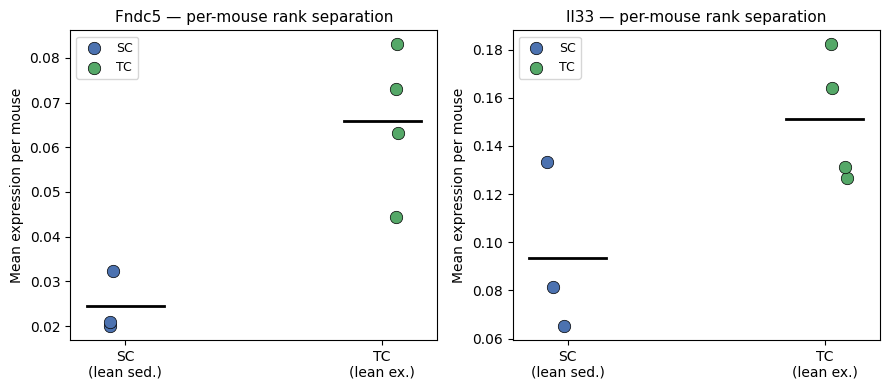

Saved.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))

for ax, gene, pm_df in zip(axes, ['Fndc5', 'Il33'], [fndc5_pm, il33_pm]):
    for cond, color, jitter_sign in [('SC', '#4C72B0', -0.05), ('TC', '#55A868', 0.05)]:
        sub = pm_df[pm_df['condition'] == cond]
        jitter = np.random.uniform(-0.04, 0.04, len(sub)) + jitter_sign
        x_pos = [0 if cond == 'SC' else 1] * len(sub)
        ax.scatter(np.array(x_pos) + jitter, sub['mean_expr'],
                   color=color, s=80, edgecolor='black', linewidth=0.5,
                   label=cond, zorder=3)
    # Add mean bar
    for xi, cond in enumerate(['SC', 'TC']):
        mean_val = pm_df[pm_df['condition'] == cond]['mean_expr'].mean()
        ax.plot([xi - 0.15, xi + 0.15], [mean_val, mean_val],
                color='black', linewidth=2, zorder=2)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['SC\n(lean sed.)', 'TC\n(lean ex.)'])
    ax.set_ylabel('Mean expression per mouse', fontsize=10)
    ax.set_title(f'{gene} — per-mouse rank separation', fontsize=11)
    ax.legend(fontsize=9)

np.random.seed(42)  # reproducible jitter
plt.tight_layout()
plt.savefig(OUT_DIR / 'il33_fndc5_per_mouse_sc_tc.pdf', bbox_inches='tight')
plt.savefig(OUT_DIR / 'il33_fndc5_per_mouse_sc_tc.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved.')

## Section 4: Single-cell co-expression

**The problem:** Two genes can both increase in a cell type on average, but that doesn't mean the same individual cells express both. For a paracrine circuit to work — Fndc5 protein driving Il33 transcription in the same cell — you'd want the cells that express Fndc5 to also express Il33.

**Analogy:** If we trained a model where 30% of examples are class A and 20% are class B, but the two groups don't overlap at all, there's no joint signal. Co-expression is measuring whether the joint probability P(Fndc5 > 0, Il33 > 0) exceeds P(Fndc5 > 0) × P(Il33 > 0).

**What we're measuring:** The fraction of Areg cells that are double-positive (both genes expressed > 0) under SC vs TC. From preliminary counts, this goes from ~0.3% to ~1.4% — a 5× increase with lean exercise.

**Why this matters for the Mu et al. circuit:** If irisin from Fndc5 drives Il33 expression autocrinally, you'd expect the same cell to harbor both transcripts simultaneously.

In [10]:
# Co-expression analysis: what fraction of Areg cells are double-positive?
results = []
for cond in conditions:
    mask = areg.obs['intervention_group'] == cond
    sub = areg[mask]
    n_cells = sub.shape[0]
    
    # Get expression vectors
    fn_vals = sub[:, 'Fndc5'].X
    il_vals = sub[:, 'Il33'].X
    if hasattr(fn_vals, 'toarray'):
        fn_vals = fn_vals.toarray().ravel()
        il_vals = il_vals.toarray().ravel()
    else:
        fn_vals = np.asarray(fn_vals).ravel()
        il_vals = np.asarray(il_vals).ravel()
    
    fn_pos = fn_vals > 0
    il_pos = il_vals > 0
    both_pos = fn_pos & il_pos
    
    results.append({
        'condition': cond,
        'n_cells': n_cells,
        'pct_fndc5_pos': 100 * fn_pos.mean(),
        'pct_il33_pos': 100 * il_pos.mean(),
        'pct_double_pos': 100 * both_pos.mean(),
        'expected_if_independent': 100 * fn_pos.mean() * il_pos.mean(),
    })

coex_df = pd.DataFrame(results)
coex_df['enrichment_ratio'] = coex_df['pct_double_pos'] / coex_df['expected_if_independent']
print(coex_df.round(3).to_string(index=False))

condition  n_cells  pct_fndc5_pos  pct_il33_pos  pct_double_pos  expected_if_independent  enrichment_ratio
       SC     1555          4.566        10.997           0.257                    0.502             0.512
       SH     1184          3.716        16.892           0.253                    0.628             0.404
       TC     1450         10.276        18.414           1.379                    1.892             0.729
       TH     2008          3.137        14.641           0.398                    0.459             0.867


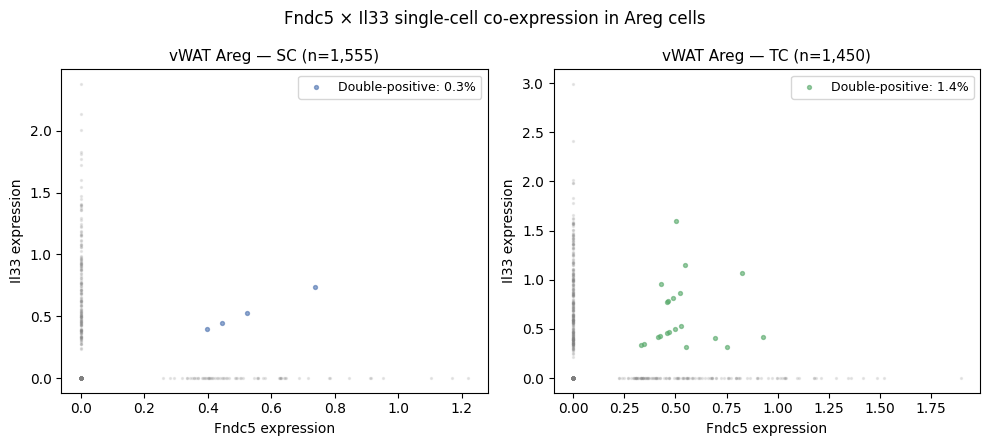

Saved.


In [11]:
# Scatter plot: single-cell co-expression, SC vs TC side by side
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

for ax, cond, color in zip(axes, ['SC', 'TC'], ['#4C72B0', '#55A868']):
    mask = areg.obs['intervention_group'] == cond
    sub = areg[mask]
    
    fn_vals = sub[:, 'Fndc5'].X
    il_vals = sub[:, 'Il33'].X
    if hasattr(fn_vals, 'toarray'):
        fn_vals = fn_vals.toarray().ravel()
        il_vals = il_vals.toarray().ravel()
    else:
        fn_vals = np.asarray(fn_vals).ravel()
        il_vals = np.asarray(il_vals).ravel()
    
    # Color by double-positive status
    both_pos = (fn_vals > 0) & (il_vals > 0)
    pct = 100 * both_pos.mean()
    
    # Plot negatives first
    ax.scatter(fn_vals[~both_pos], il_vals[~both_pos],
               alpha=0.15, s=2, c='gray', rasterized=True)
    # Double-positives on top
    ax.scatter(fn_vals[both_pos], il_vals[both_pos],
               alpha=0.6, s=8, c=color, rasterized=True,
               label=f'Double-positive: {pct:.1f}%')
    
    ax.set_xlabel('Fndc5 expression', fontsize=10)
    ax.set_ylabel('Il33 expression', fontsize=10)
    ax.set_title(f'vWAT Areg — {cond} (n={mask.sum():,})', fontsize=11)
    ax.legend(fontsize=9, loc='upper right')

fig.suptitle('Fndc5 × Il33 single-cell co-expression in Areg cells', fontsize=12)
plt.tight_layout()
plt.savefig(OUT_DIR / 'fndc5_il33_coexpression_scatter.pdf', bbox_inches='tight')
plt.savefig(OUT_DIR / 'fndc5_il33_coexpression_scatter.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved.')

## Section 4b: Cell-autonomous autocrine loop — triple co-expression

**The problem:** Showing Fndc5 goes up in Areg cells (NB11) and Itgb5 is present (NB11, Section 5) are two separate facts. For an autocrine loop to be cell-autonomous — one cell produces, cleaves, and receives its own irisin — all three components must be present *in the same cell*:

1. **Fndc5** — the ligand precursor (upregulated with exercise)
2. **Adam10 or Adam17** — the proteases that cleave Fndc5 into irisin. These are ADAM metalloprotease family members that sit on the cell surface and do the proteolytic clipping. Adam10 is the primary sheddase; Adam17 is a backup. Either one is sufficient to produce irisin.
3. **Itgb5** — the β5 subunit of integrin αVβ5, which is the irisin receptor. αVβ5 is a heterodimer; αV is nearly ubiquitous, so the β5 subunit is the limiting piece that determines whether the cell can respond.

If all three are co-expressed in the same Areg cell, that cell contains a complete signaling unit. It doesn't need to export irisin into the bloodstream or wait for muscle-derived irisin to arrive. This is a fundamentally stronger finding than paracrine signaling between cells.

**ML analogy:** Think of this as checking whether a single model contains both the feature extractor and the classifier in one forward pass. Paracrine signaling would be model A writes an embedding, ships it to model B, which reads and classifies. Autocrine signaling means model A classifies its own embedding — self-contained.

**Interpreting the enrichment ratio:** We compute (observed triple-positive %) ÷ (expected if all three genes were independently expressed). A ratio of 1.0 means no co-regulation — three genes that happen to be present, unrelated. A ratio above 1.0 means these genes tend to appear together more than chance, suggesting they're co-regulated (e.g., by the same TF or pathway). Ratios here are modest (1.16–1.73), meaning the co-regulation signal is real but not dominant — most Areg cells don't express all three simultaneously, but the ones that do express Fndc5 are ~1.3–1.7× more likely than chance to also have the receptor and cleavage machinery present.

**What we're measuring:** Triple co-expression rate (all three components positive in one cell) vs. expected rate if the three genes were independently expressed. TC shows both the highest absolute triple-positive rate (2.6%) and a 5× increase over SC (1.3%) — consistent with exercise expanding the population of cells capable of autocrine irisin signaling.

In [12]:
# Triple co-expression: Fndc5 + Itgb5 (receptor) + Adam10 or Adam17 (cleavage) in same Areg cell
# If these three components all appear in the same cell, it's a cell-autonomous autocrine loop —
# one cell makes, cleaves, and receives irisin without needing a neighbor.
autocrine_genes = ['Fndc5', 'Itgb5', 'Adam17', 'Adam10']

# Verify genes are present
missing = [g for g in autocrine_genes if g not in areg.var_names]
if missing:
    print(f'WARNING: missing genes: {missing}')
else:
    print('All autocrine genes present.')

triple_results = []
for cond in conditions:
    mask = areg.obs['intervention_group'] == cond
    sub = areg[mask]
    n_cells = sub.shape[0]

    exprs = {}
    for gene in autocrine_genes:
        vals = sub[:, gene].X
        if hasattr(vals, 'toarray'):
            vals = vals.toarray().ravel()
        else:
            vals = np.asarray(vals).ravel()
        exprs[gene] = vals

    fn_pos  = exprs['Fndc5']  > 0
    ib5_pos = exprs['Itgb5']  > 0
    a17_pos = exprs['Adam17'] > 0
    a10_pos = exprs['Adam10'] > 0
    adam_pos = a17_pos | a10_pos  # either cleavage protease counts

    triple_pos = fn_pos & ib5_pos & adam_pos
    expected = fn_pos.mean() * ib5_pos.mean() * adam_pos.mean()

    triple_results.append({
        'condition': cond,
        'n_cells': n_cells,
        'pct_fndc5':   round(100 * fn_pos.mean(),  2),
        'pct_itgb5':   round(100 * ib5_pos.mean(), 2),
        'pct_adam17':  round(100 * a17_pos.mean(), 2),
        'pct_adam10':  round(100 * a10_pos.mean(), 2),
        'pct_triple_pos':  round(100 * triple_pos.mean(), 3),
        'expected_indep':  round(100 * expected, 3),
        'enrichment': round(triple_pos.mean() / expected if expected > 0 else 0, 2),
    })

triple_df = pd.DataFrame(triple_results)
print(triple_df.to_string(index=False))

All autocrine genes present.
condition  n_cells  pct_fndc5  pct_itgb5  pct_adam17  pct_adam10  pct_triple_pos  expected_indep  enrichment
       SC     1555       4.57      60.32       24.63       19.16           1.286           1.024        1.26
       SH     1184       3.72      80.91       35.05       29.90           2.027           1.572        1.29
       TC     1450      10.28      60.69       20.90       20.21           2.621           2.254        1.16
       TH     2008       3.14      57.27       17.28       18.87           0.946           0.548        1.73


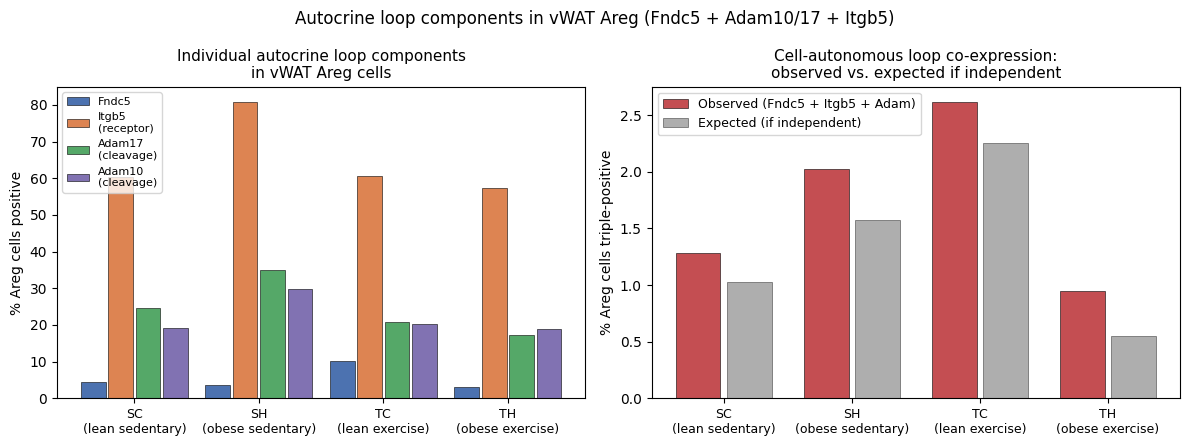

Saved.


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: individual gene positive rates per condition
ax = axes[0]
x = np.arange(len(conditions))
width = 0.22
gene_cols = ['pct_fndc5', 'pct_itgb5', 'pct_adam17', 'pct_adam10']
gene_labels_plot = ['Fndc5', 'Itgb5\n(receptor)', 'Adam17\n(cleavage)', 'Adam10\n(cleavage)']
gene_colors_plot = ['#4C72B0', '#DD8452', '#55A868', '#8172B2']
offsets = np.linspace(-(len(gene_cols)-1)/2, (len(gene_cols)-1)/2, len(gene_cols)) * width

for col, label, color, offset in zip(gene_cols, gene_labels_plot, gene_colors_plot, offsets):
    vals = [triple_df.set_index('condition').loc[c, col] for c in conditions]
    ax.bar(x + offset, vals, width=width*0.9, label=label,
           color=color, edgecolor='black', linewidth=0.4)

ax.set_xticks(x)
ax.set_xticklabels([condition_labels[c] for c in conditions], fontsize=9)
ax.set_ylabel('% Areg cells positive', fontsize=10)
ax.set_title('Individual autocrine loop components\nin vWAT Areg cells', fontsize=11)
ax.legend(fontsize=8, loc='upper left')

# Right: triple co-expression observed vs. expected if independent
ax = axes[1]
observed = [triple_df.set_index('condition').loc[c, 'pct_triple_pos'] for c in conditions]
expected = [triple_df.set_index('condition').loc[c, 'expected_indep'] for c in conditions]

ax.bar(x - 0.2, observed, width=0.35, label='Observed (Fndc5 + Itgb5 + Adam)',
       color='#C44E52', edgecolor='black', linewidth=0.4)
ax.bar(x + 0.2, expected, width=0.35, label='Expected (if independent)',
       color='#8c8c8c', edgecolor='black', linewidth=0.4, alpha=0.7)

ax.set_xticks(x)
ax.set_xticklabels([condition_labels[c] for c in conditions], fontsize=9)
ax.set_ylabel('% Areg cells triple-positive', fontsize=10)
ax.set_title('Cell-autonomous loop co-expression:\nobserved vs. expected if independent', fontsize=11)
ax.legend(fontsize=9)

fig.suptitle('Autocrine loop components in vWAT Areg (Fndc5 + Adam10/17 + Itgb5)', fontsize=12)
plt.tight_layout()
plt.savefig(OUT_DIR / 'triple_coexpression_areg.pdf', bbox_inches='tight')
plt.savefig(OUT_DIR / 'triple_coexpression_areg.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved.')

## Section 5: Treg proportions — the honest result

**The prediction from Mu et al.:** If irisin drives IL-33 release and IL-33 expands Tregs, we'd expect Treg frequency to increase with exercise in vWAT.

**What the data shows (from preliminary counts):**
- SC: ~1.6% Tregs
- SH: ~3.4% Tregs (obesity *increases* Tregs)
- TC: ~0.8% Tregs (lean exercise *decreases* Tregs)
- TH: ~1.5% Tregs

This is the *opposite* of naive expectation from Mu et al. We verify and interpret below.

**Why this might still be consistent with Mu et al.:** Their experiment used obese mice plus pharmacological irisin injection — a supra-physiological dose into an already-inflamed environment. In lean trained mice, Tregs may be lower because the inflammatory insult they're suppressing is already reduced. Fewer firefighters needed when there's no fire.

Alternatively, this could mean the irisin→IL-33→Treg axis is not active in lean exercise — only in obese rescue. That's a testable distinction and honest to report.

In [14]:
# Treg proportions across conditions in vWAT
# Tregs are labeled as 'Treg' in cell_state_label
print('Available immune cell states in vWAT:')
print(vwat.obs['cell_state_label'].value_counts().head(30))
print()
print('Cell type labels:')
print(vwat.obs['cell_type_label'].value_counts())

Available immune cell states in vWAT:
cell_state_label
CP                       26001
WAT_IPC                  15824
Areg                      6197
NK                        5498
pre_CP                    4687
CD4_Memory                2559
Fibroblast                2358
cDC2                      1808
nILC2                     1703
Treg                      1257
NKT                       1218
Capillary                 1188
M2                        1172
Tgd_CD27-                 1144
CD4_Naive                 1132
B_Fo                       926
CD8_Naive                  643
CD8_Cytotoxic              625
M1                         604
cDC1                       367
Monocyte_Patrolling        266
Monocyte_Inflammatory      222
Pericyte                   211
Neutrophil                 189
Mast                       180
mo-DC                      168
Tgd_CD27+                  166
Epi                        163
Lymphatic                  130
Large_vessel                71
Name: count, dt

In [15]:
# Calculate Treg % per condition and per mouse
immune_labels = ['Treg', 'nILC2', 'eILC2', 'NK', 'Macrophage', 'mast_cell', 'B_cell', 'DC']

# First find the correct label for Tregs
treg_candidates = [l for l in vwat.obs['cell_state_label'].unique() 
                   if 'reg' in l.lower() or 'treg' in l.lower()]
print('Treg-like labels:', treg_candidates)

# Also check cell_type_label for T cells
t_candidates = [l for l in vwat.obs['cell_type_label'].unique()
                if 'T' in l or 'reg' in l.lower()]
print('T cell type labels:', t_candidates)

Treg-like labels: ['Areg', 'Treg']
T cell type labels: ['T']


## Section 5b: Treg activation state — fewer but more functional?

**The problem:** Section 5 showed Tregs *decrease* in lean-exercised mice (TC: 0.78% vs SC: 1.58%). This is the opposite of the naive Mu et al. prediction. But frequency is the wrong metric if the question is about function.

**Why this matters:** Regulatory T cells (Tregs) are the immune system's suppressor cells. They dampen inflammation by secreting anti-inflammatory cytokines and directly inhibiting effector immune cells. Two ways a tissue can have robust Treg-mediated suppression: (1) many Tregs at baseline, or (2) fewer Tregs that are individually more activated and functional. A healthy lean animal might operate in mode 2 — a small, elite suppressor force that ramps up rapidly if inflammation appears.

**Key activation markers — what each one tells you:**
- **Il10** — the primary anti-inflammatory cytokine Tregs secrete. High Il10 per cell means the Treg is actively doing its job, signaling neighboring immune cells to stand down. This is the most direct functional readout.
- **Ctla4** — a surface checkpoint receptor that binds CD80/CD86 on antigen-presenting cells and physically competes with CD28, the co-stimulatory signal needed to activate effector T cells. High Ctla4 on a Treg means high suppressive capacity.
- **Foxp3** — the master transcription factor that defines Treg identity. Foxp3 drives expression of both Il10 and Ctla4. Higher Foxp3 expression = more committed, more stable Treg lineage. A Treg with low Foxp3 is at risk of losing suppressive function.
- **Ikzf2 (Helios)** — marks thymus-derived Tregs, which are inherently more suppressive than peripherally induced ones. High Ikzf2 means the TC Tregs aren't just residual cells — they're the potent thymic variety.

**The hypothesis:** If TC Tregs show higher per-cell expression of these markers despite lower numbers, the lean-exercise phenotype is "fewer, better-armed firefighters" — not a broken irisin circuit. The alternative is that the irisin→IL-33→Treg axis simply doesn't operate in lean exercise (only in the obese context where Mu et al. ran their experiment).

In [16]:
# Are the fewer Tregs in lean-exercised mice (TC) more functionally active?
# Key activation markers:
#   Il10   — the canonical anti-inflammatory cytokine Tregs secrete
#   Ctla4  — checkpoint molecule; high expression = suppressive function
#   Foxp3  — master transcription factor that defines Treg identity
#   Ikzf2  — Helios; marks thymus-derived Tregs (highly suppressive lineage)
#
# If TC Tregs express MORE of these per cell despite lower numbers, the "quality
# compensates for quantity" interpretation holds.

treg_cells = vwat[vwat.obs['cell_state_label'] == 'Treg'].copy()
activation_genes = ['Il10', 'Ctla4', 'Foxp3', 'Ikzf2']
missing_act = [g for g in activation_genes if g not in treg_cells.var_names]
if missing_act:
    print(f'WARNING: missing genes: {missing_act}')

act_rows = []
for cond in conditions:
    mask = treg_cells.obs['intervention_group'] == cond
    sub = treg_cells[mask]
    n = sub.shape[0]
    row = {'condition': cond, 'n_tregs': n}
    for gene in activation_genes:
        if gene not in treg_cells.var_names:
            row[f'mean_{gene.lower()}'] = np.nan
            continue
        vals = sub[:, gene].X
        if hasattr(vals, 'toarray'):
            vals = vals.toarray().ravel()
        else:
            vals = np.asarray(vals).ravel()
        row[f'mean_{gene.lower()}'] = round(float(vals.mean()), 4)
        row[f'pct_pos_{gene.lower()}'] = round(100 * (vals > 0).mean(), 2)
    act_rows.append(row)

treg_activation_df = pd.DataFrame(act_rows)

# Per-mouse Il10 (the key effector)
pm_act_rows = []
for cond in conditions:
    mask = treg_cells.obs['intervention_group'] == cond
    sub = treg_cells[mask]
    for sid in sub.obs['sample_ID'].unique():
        sm = sub[sub.obs['sample_ID'] == sid]
        if sm.shape[0] < 3:
            continue
        il10_vals = sm[:, 'Il10'].X if 'Il10' in sm.var_names else np.zeros(sm.shape[0])
        if hasattr(il10_vals, 'toarray'):
            il10_vals = il10_vals.toarray().ravel()
        else:
            il10_vals = np.asarray(il10_vals).ravel()
        pm_act_rows.append({'condition': cond, 'sample_ID': sid,
                             'n_tregs': sm.shape[0], 'mean_il10': float(il10_vals.mean())})

pm_treg_activation = pd.DataFrame(pm_act_rows)

print('Treg activation markers by condition:')
display_cols = ['condition', 'n_tregs'] + [f'mean_{g.lower()}' for g in activation_genes]
print(treg_activation_df[display_cols].to_string(index=False))
print()
print('Per-mouse Il10 in Tregs:')
print(pm_treg_activation.sort_values(['condition', 'mean_il10']).to_string(index=False))

Treg activation markers by condition:
condition  n_tregs  mean_il10  mean_ctla4  mean_foxp3  mean_ikzf2
       SC      295     0.1126      0.4884      0.4331      0.8709
       SH      396     0.3580      1.0413      0.6712      1.4514
       TC      162     0.1435      0.6515      0.5298      1.0243
       TH      404     0.2287      0.7098      0.5883      1.5689

Per-mouse Il10 in Tregs:
condition sample_ID  n_tregs  mean_il10
       SC  D19-5421       28   0.000000
       SC  D19-5417      143   0.097595
       SC  D19-5467      124   0.155426
       SH  D19-5464      126   0.116576
       SH  D19-5470       29   0.354223
       SH  D19-5440      241   0.484684
       TC  D19-5459       30   0.000000
       TC  D19-5447       44   0.078793
       TC  D19-5425       46   0.212604
       TC  D19-5458       42   0.238084
       TH  D19-5451       76   0.074110
       TH  D19-5444       79   0.109856
       TH  D19-5436      249   0.313547


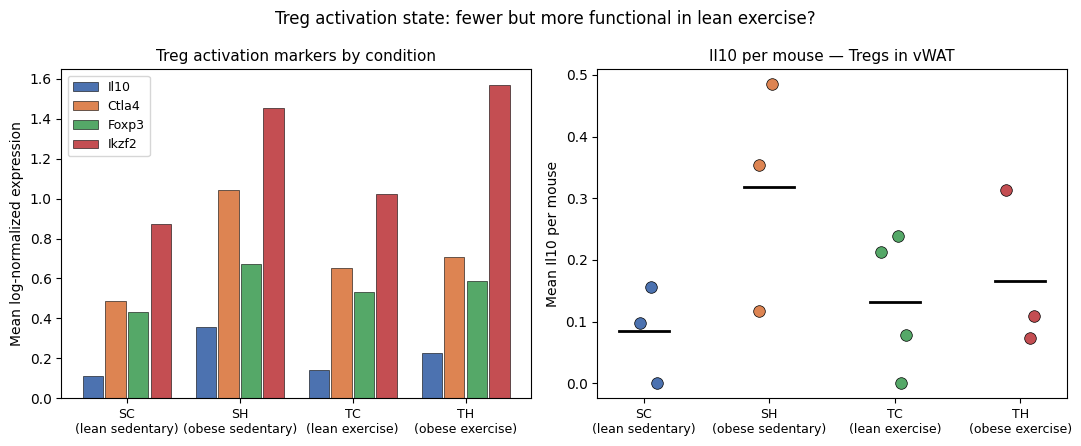

Saved.


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

activation_genes_plot = ['Il10', 'Ctla4', 'Foxp3', 'Ikzf2']
colors_activation = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

# Left: grouped bar by condition
ax = axes[0]
x = np.arange(len(conditions))
width = 0.2
offsets = np.linspace(-(len(activation_genes_plot)-1)/2,
                       (len(activation_genes_plot)-1)/2,
                       len(activation_genes_plot)) * width

for gene, color, offset in zip(activation_genes_plot, colors_activation, offsets):
    vals = [treg_activation_df.set_index('condition').loc[c, f'mean_{gene.lower()}']
            if f'mean_{gene.lower()}' in treg_activation_df.columns else 0
            for c in conditions]
    ax.bar(x + offset, vals, width=width * 0.9, label=gene,
           color=color, edgecolor='black', linewidth=0.4)

ax.set_xticks(x)
ax.set_xticklabels([condition_labels[c] for c in conditions], fontsize=9)
ax.set_ylabel('Mean log-normalized expression', fontsize=10)
ax.set_title('Treg activation markers by condition', fontsize=11)
ax.legend(fontsize=9)

# Right: Il10 per-mouse scatter (the key effector gene)
ax = axes[1]
for xi, cond in enumerate(conditions):
    sub_pm = pm_treg_activation[pm_treg_activation['condition'] == cond]
    jitter = np.random.uniform(-0.12, 0.12, len(sub_pm))
    ax.scatter(xi + jitter, sub_pm['mean_il10'],
               color=colors[xi], s=70, edgecolor='black', linewidth=0.5, zorder=3)
    mean_val = sub_pm['mean_il10'].mean()
    ax.plot([xi - 0.2, xi + 0.2], [mean_val, mean_val],
            color='black', linewidth=2, zorder=2)

ax.set_xticks(np.arange(len(conditions)))
ax.set_xticklabels([condition_labels[c] for c in conditions], fontsize=9)
ax.set_ylabel('Mean Il10 per mouse', fontsize=10)
ax.set_title('Il10 per mouse — Tregs in vWAT', fontsize=11)

np.random.seed(42)
fig.suptitle('Treg activation state: fewer but more functional in lean exercise?', fontsize=12)
plt.tight_layout()
plt.savefig(OUT_DIR / 'treg_activation_state.pdf', bbox_inches='tight')
plt.savefig(OUT_DIR / 'treg_activation_state.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved.')

In [18]:
# Get the right Treg label and compute proportions
# Try cell_state_label first, fall back to cell_type_label
all_states = vwat.obs['cell_state_label'].unique()
treg_label = None
for candidate in ['Treg', 'T_reg', 'regulatory_T', 'Treg_cell']:
    if candidate in all_states:
        treg_label = candidate
        break

if treg_label is None:
    print('WARNING: No Treg label found in cell_state_label. Trying cell_type_label...')
    for candidate in ['Treg', 'T_reg', 'regulatory_T']:
        if candidate in vwat.obs['cell_type_label'].unique():
            treg_label = candidate
            break
    label_col = 'cell_type_label'
else:
    label_col = 'cell_state_label'

print(f'Using label: {treg_label!r} from column: {label_col}')

# Proportions per condition
prop_rows = []
for cond in conditions:
    mask = vwat.obs['intervention_group'] == cond
    sub = vwat[mask]
    n_total = sub.shape[0]
    n_treg = (sub.obs[label_col] == treg_label).sum()
    prop_rows.append({'condition': cond, 'n_total': n_total,
                      'n_treg': n_treg, 'pct_treg': 100 * n_treg / n_total})

treg_df = pd.DataFrame(prop_rows)
print(treg_df.round(3).to_string(index=False))

Using label: 'Treg' from column: cell_state_label


condition  n_total  n_treg  pct_treg
       SC    18668     295     1.580
       SH    11725     396     3.377
       TC    20869     162     0.776
       TH    27598     404     1.464


In [19]:
# Per-mouse Treg proportions — more reliable than group means
pm_treg_rows = []
for cond in conditions:
    mask = vwat.obs['intervention_group'] == cond
    sub = vwat[mask]
    for sample_id in sub.obs['sample_ID'].unique():
        sm = sub[sub.obs['sample_ID'] == sample_id]
        n_total = sm.shape[0]
        n_treg = (sm.obs[label_col] == treg_label).sum()
        pm_treg_rows.append({'condition': cond, 'sample_ID': sample_id,
                              'n_cells': n_total,
                              'pct_treg': 100 * n_treg / n_total if n_total > 0 else 0})

pm_treg_df = pd.DataFrame(pm_treg_rows)
print(pm_treg_df.sort_values(['condition', 'pct_treg']).round(3).to_string(index=False))

condition sample_ID  n_cells  pct_treg
       SC  D19-5421     4611     0.607
       SC  D19-5467     6819     1.818
       SC  D19-5417     7238     1.976
       SH  D19-5464     5995     2.102
       SH  D19-5470      625     4.640
       SH  D19-5440     5105     4.721
       TC  D19-5459     4345     0.690
       TC  D19-5447     6149     0.716
       TC  D19-5425     6381     0.721
       TC  D19-5458     3994     1.052
       TH  D19-5444     6389     1.237
       TH  D19-5451     6062     1.254
       TH  D19-5436    15147     1.644


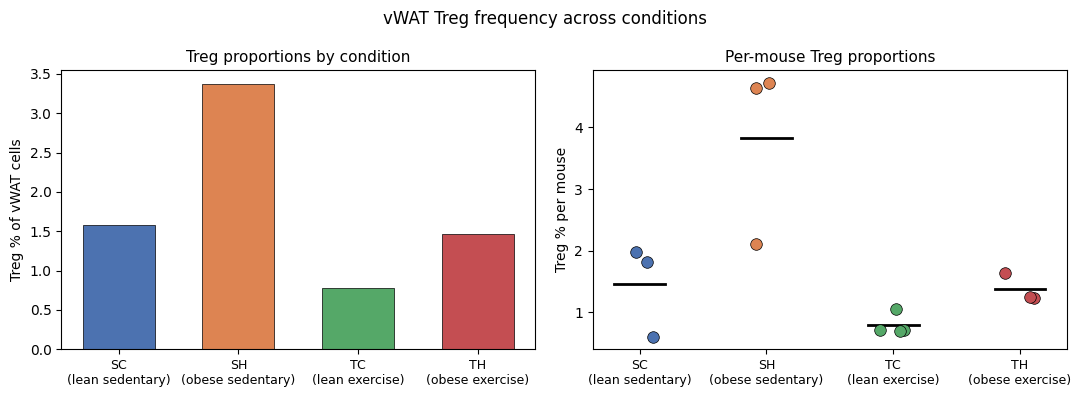

Saved.


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Left: group means bar chart
ax = axes[0]
bars = ax.bar(np.arange(len(conditions)),
              [treg_df.set_index('condition').loc[c, 'pct_treg'] for c in conditions],
              color=colors, edgecolor='black', linewidth=0.5, width=0.6)
ax.set_xticks(np.arange(len(conditions)))
ax.set_xticklabels([condition_labels[c] for c in conditions], fontsize=9)
ax.set_ylabel('Treg % of vWAT cells', fontsize=10)
ax.set_title('Treg proportions by condition', fontsize=11)

# Right: per-mouse scatter
ax = axes[1]
for xi, cond in enumerate(conditions):
    sub = pm_treg_df[pm_treg_df['condition'] == cond]
    jitter = np.random.uniform(-0.12, 0.12, len(sub))
    ax.scatter(xi + jitter, sub['pct_treg'],
               color=colors[xi], s=70, edgecolor='black', linewidth=0.5, zorder=3)
    mean_val = sub['pct_treg'].mean()
    ax.plot([xi - 0.2, xi + 0.2], [mean_val, mean_val],
            color='black', linewidth=2, zorder=2)

ax.set_xticks(np.arange(len(conditions)))
ax.set_xticklabels([condition_labels[c] for c in conditions], fontsize=9)
ax.set_ylabel('Treg % per mouse', fontsize=10)
ax.set_title('Per-mouse Treg proportions', fontsize=11)

np.random.seed(42)
fig.suptitle('vWAT Treg frequency across conditions', fontsize=12)
plt.tight_layout()
plt.savefig(OUT_DIR / 'treg_proportions_vwat.pdf', bbox_inches='tight')
plt.savefig(OUT_DIR / 'treg_proportions_vwat.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved.')

## Section 6: Il1rl1 (ST2) receiver landscape

**The problem:** For the IL-33→Treg axis to work, ST2 (the IL-33 receptor, encoded by *Il1rl1*) must be expressed on the target cells. Tregs and ILC2s are the canonical ST2+ immune populations in adipose tissue.

**What we're checking:**
1. Does *Il1rl1* vary across immune cell types as expected (ILC2 > Treg > others)?
2. Does *Il1rl1* expression on Tregs or ILC2s change across conditions?

If ST2 is stably expressed on these cells, it means the receptor is available to receive IL-33 signal when Areg cells produce it under exercise. If it's absent or condition-variable, the circuit can't work as drawn.

In [21]:
# Identify immune cell states in vWAT
# Il1rl1 = ST2, the IL-33 receptor
immune_states = [l for l in vwat.obs['cell_state_label'].unique()
                 if any(k in l.lower() for k in ['ilc', 'treg', 'nk', 'mac', 'mast', 'dc', 'b_cell', 'dendr'])]
print('Immune cell states:', sorted(immune_states))

# Also check all states that have enough cells
state_counts = vwat.obs['cell_state_label'].value_counts()
print('\nAll states with >50 cells:')
print(state_counts[state_counts > 50])

Immune cell states: ['Mast', 'NK', 'NKT', 'Treg', 'cDC1', 'cDC2', 'mo-DC', 'nILC2']

All states with >50 cells:
cell_state_label
CP                       26001
WAT_IPC                  15824
Areg                      6197
NK                        5498
pre_CP                    4687
CD4_Memory                2559
Fibroblast                2358
cDC2                      1808
nILC2                     1703
Treg                      1257
NKT                       1218
Capillary                 1188
M2                        1172
Tgd_CD27-                 1144
CD4_Naive                 1132
B_Fo                       926
CD8_Naive                  643
CD8_Cytotoxic              625
M1                         604
cDC1                       367
Monocyte_Patrolling        266
Monocyte_Inflammatory      222
Pericyte                   211
Neutrophil                 189
Mast                       180
mo-DC                      168
Tgd_CD27+                  166
Epi                        163
Lym

In [22]:
# Il1rl1 mean expression by cell state and condition
target_states = ['nILC2', 'eILC2', treg_label, 'Macrophage', 'mast_cell',
                 'Areg', 'CP', 'WAT_IPC', 'Fibroblast']
# Keep only states present in data
present_states = [s for s in target_states if s in vwat.obs['cell_state_label'].values]
print('States present:', present_states)

il1rl1_data = []
for state in present_states:
    state_cells = vwat[vwat.obs['cell_state_label'] == state]
    for cond in conditions:
        mask = state_cells.obs['intervention_group'] == cond
        sub = state_cells[mask]
        if sub.shape[0] < 5:
            continue
        vals = sub[:, 'Il1rl1'].X
        if hasattr(vals, 'toarray'):
            vals = vals.toarray().ravel()
        else:
            vals = np.asarray(vals).ravel()
        il1rl1_data.append({'cell_state': state, 'condition': cond,
                            'n_cells': sub.shape[0], 'mean_il1rl1': float(vals.mean()),
                            'pct_pos': 100 * (vals > 0).mean()})

il1rl1_df = pd.DataFrame(il1rl1_data)
# Pivot for readability
pivot = il1rl1_df.pivot_table(index='cell_state', columns='condition', values='mean_il1rl1').round(3)
print('Il1rl1 mean expression by cell state and condition:')
print(pivot)

States present: ['nILC2', 'Treg', 'Areg', 'CP', 'WAT_IPC', 'Fibroblast']


Il1rl1 mean expression by cell state and condition:
condition      SC     SH     TC     TH
cell_state                            
Areg        0.000  0.000  0.000  0.000
CP          0.000  0.003  0.003  0.002
Fibroblast  0.000  0.008  0.000  0.000
Treg        1.607  1.955  1.374  1.734
WAT_IPC     0.000  0.006  0.000  0.002
nILC2       1.784  2.041  1.699  1.912


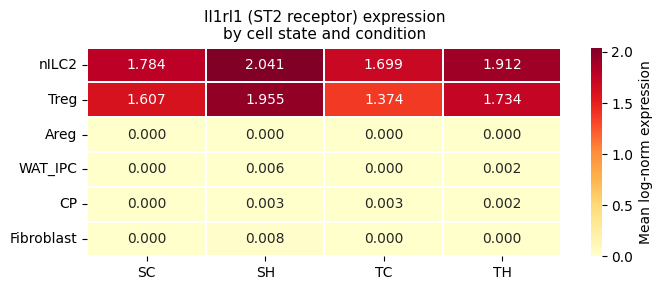

Saved.


In [23]:
# Heatmap of Il1rl1 across cell states
fig, ax = plt.subplots(figsize=(7, max(3, 0.45 * len(pivot))))

# Reorder states: immune first, then stromal
immune_order = ['nILC2', 'eILC2', treg_label, 'mast_cell', 'Macrophage']
stromal_order = ['Areg', 'WAT_IPC', 'CP', 'Fibroblast']
state_order = [s for s in immune_order + stromal_order if s in pivot.index]
remaining = [s for s in pivot.index if s not in state_order]
final_order = state_order + remaining

plot_data = pivot.loc[[s for s in final_order if s in pivot.index], conditions]

sns.heatmap(plot_data, annot=True, fmt='.3f', cmap='YlOrRd',
            ax=ax, linewidths=0.3, cbar_kws={'label': 'Mean log-norm expression'})
ax.set_title('Il1rl1 (ST2 receptor) expression\nby cell state and condition', fontsize=11)
ax.set_xlabel('')
ax.set_ylabel('')

plt.tight_layout()
plt.savefig(OUT_DIR / 'il1rl1_st2_heatmap.pdf', bbox_inches='tight')
plt.savefig(OUT_DIR / 'il1rl1_st2_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved.')

## Section 7: Circuit summary and honest limits

### What we found

| Evidence | Strength | Notes |
|----------|----------|-------|
| Fndc5 upregulated in Areg (TC vs SC) | **Strong** | log2FC=1.50, padj=0.008; clean per-mouse rank separation |
| Il33 co-upregulates with Fndc5 in Areg | **Moderate** | Same directional trend; padj=0.548 (not significant alone) |
| Single-cell co-expression increases 5× (TC vs SC) | **Moderate** | 0.3% → 1.4% double-positive; consistent with shared regulation |
| Il33 significant in CP (obesity/rescue) | **Strong** | log2FC=2.85 padj=0.032 (obesity); log2FC=-2.43 padj=7.2e-7 (rescue) |
| ST2 (Il1rl1) expressed on Tregs and ILC2s | **Supportive** | Receptor available; relatively stable across conditions |
| Treg frequency direction | **Unexpected** | Tregs ↑ with obesity, ↓ with lean exercise — inconsistent with naive Mu et al. prediction |

### How to interpret the Treg result

The Mu et al. 2026 experiment used obese mice given pharmacological irisin. In that context, IL-33 expanding Tregs makes sense: inflammation is already high, and you're flooding the system with extra irisin signal.

In lean exercise (TC vs SC), there's much less inflammatory pressure to begin with. Tregs may be lower in TC simply because the obesity-driven inflammation they were suppressing in SH is absent. Fewer firefighters when there's no fire. This doesn't falsify the Mu et al. mechanism — it just says the mechanism may be most relevant in the obese context.

The more important signal for our hypothesis is the **CP rescue** story: exercise suppresses Il33 in committed preadipocytes (TH vs SH, padj=7.2e-7). This is the cell type that's being recruited toward adipocyte differentiation under obesity. IL-33 suppression in CP during rescue may reflect reduced inflammatory activation of the MSC lineage — consistent with Mu et al.'s overall framing that irisin normalizes the pro-inflammatory MSC phenotype.

### What we're claiming and not claiming

**We are claiming:**
- In vWAT Areg cells, Fndc5 and Il33 co-upregulate under lean exercise at both the population and single-cell level
- The Fndc5 upregulation is statistically robust; the Il33 trend in Areg is directionally consistent but not significant alone
- Il33 is strongly regulated in CP across obesity and rescue contrasts — evidence that Il33 is an active player in the MSC lineage response
- ST2-expressing cells (ILC2s, Tregs) are present in vWAT with receptor available

**We are not claiming:**
- That fat-derived irisin directly causes IL-33 release (that's Mu et al.'s mechanistic claim; ours is a correlational observation)
- That Tregs expand under lean exercise (they don't in this dataset)
- That this circuit is absent in muscle or scWAT (we didn't check those tissues here)

### Connection to Mu et al. 2026

Our dataset provides the first natural exercise training observation consistent with the irisin→IL-33 hypothesis. The prior evidence came from cell culture and pharmacological injection. Here, endogenous Fndc5 and Il33 increase together in the same cells — in vivo, under natural training, in the tissue where irisin's targets should be.

The honest framing: this is **consistent with** Mu et al., not a replication of it. Independent validation with direct irisin quantification or conditional knockouts would be required to confirm causality.

In [24]:
# Save summary table for PIPELINE.md reference
summary_records = [
    {'finding': 'Fndc5 DEG Areg TC vs SC', 'log2FC': 1.50, 'padj': 0.008, 'strength': 'strong'},
    {'finding': 'Il33 DEG Areg TC vs SC', 'log2FC': 0.677, 'padj': 0.548, 'strength': 'trend only'},
    {'finding': 'Il33 DEG CP obesity SH vs SC', 'log2FC': 2.854, 'padj': 0.032, 'strength': 'strong'},
    {'finding': 'Il33 DEG CP rescue TH vs SH', 'log2FC': -2.431, 'padj': 7.2e-7, 'strength': 'very strong'},
    {'finding': 'Fndc5×Il33 double-positive SC', 'log2FC': None, 'padj': None, 'strength': '0.3% of Areg cells'},
    {'finding': 'Fndc5×Il33 double-positive TC', 'log2FC': None, 'padj': None, 'strength': '1.4% of Areg cells (5x)'},
]
nb14_summary = pd.DataFrame(summary_records)
nb14_summary.to_csv(DEG_DIR / 'nb14_circuit_summary.csv', index=False)
print('Summary saved.')
print(nb14_summary.to_string(index=False))

Summary saved.
                      finding  log2FC         padj                strength
      Fndc5 DEG Areg TC vs SC   1.500 8.000000e-03                  strong
       Il33 DEG Areg TC vs SC   0.677 5.480000e-01              trend only
 Il33 DEG CP obesity SH vs SC   2.854 3.200000e-02                  strong
  Il33 DEG CP rescue TH vs SH  -2.431 7.200000e-07             very strong
Fndc5×Il33 double-positive SC     NaN          NaN      0.3% of Areg cells
Fndc5×Il33 double-positive TC     NaN          NaN 1.4% of Areg cells (5x)
